# LAB 2.2 - Hopfield Network

Assignment on binary image recall with asynchronous state updates.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from hopfield_numpy import (
    HopfieldNetwork,
    distort_pattern,
    load_patterns,
    plot_dynamics,
    plot_reconstruction,
)


Matplotlib is building the font cache; this may take a moment.


In [2]:
FIG_DIR = PROJECT_ROOT / "figures"
RES_DIR = PROJECT_ROOT / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

patterns = load_patterns(PROJECT_ROOT / "data", pattern_ids=[0, 1, 2])
print("Pattern matrix shape:", patterns.shape)


Pattern matrix shape: (3, 1024)


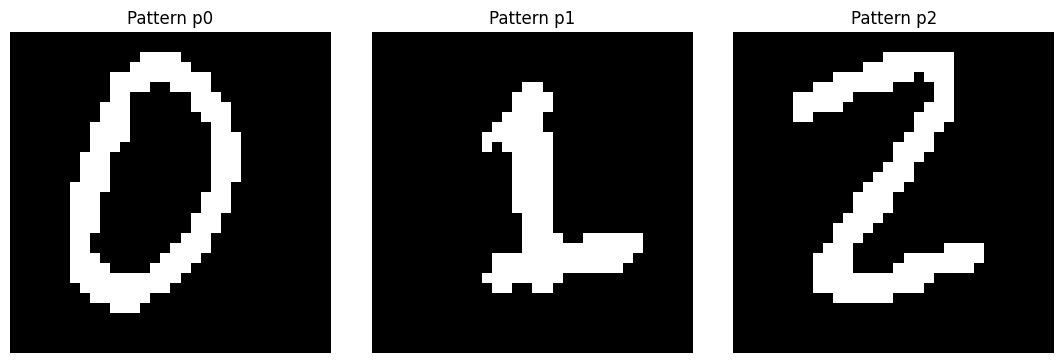

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for i in range(3):
    axes[i].imshow(patterns[i].reshape(32, 32), cmap="gray")
    axes[i].set_title(f"Pattern p{i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


MSE with 0.05 of noise: 0.1562


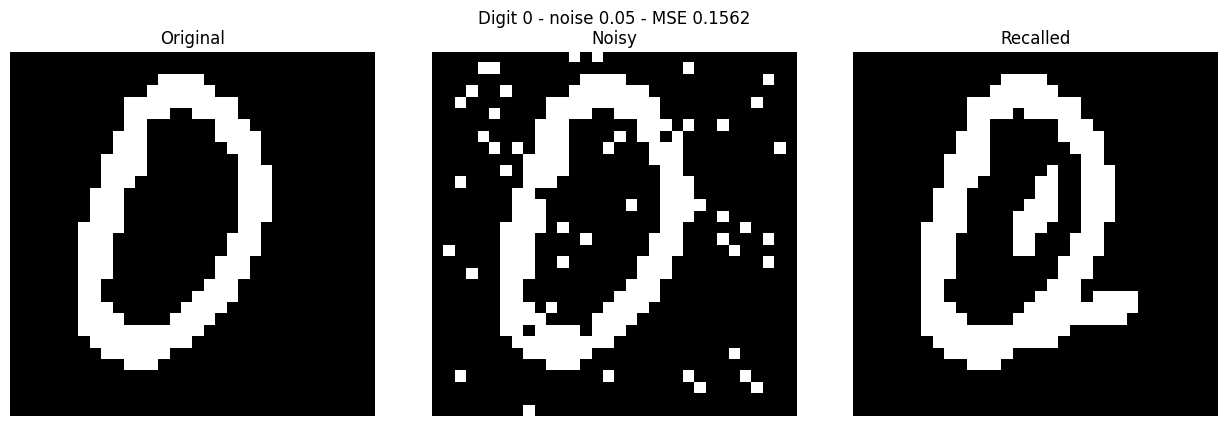

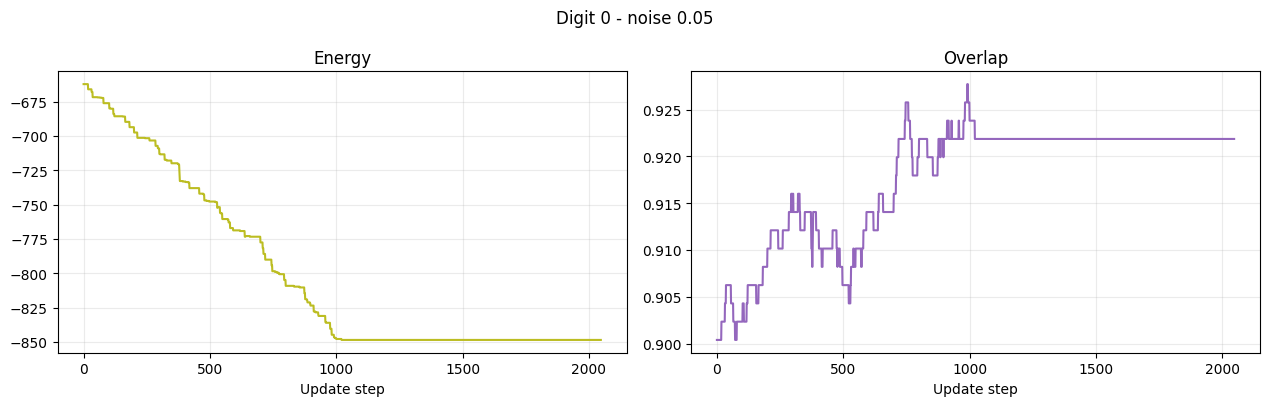

MSE with 0.1 of noise: 0.1562


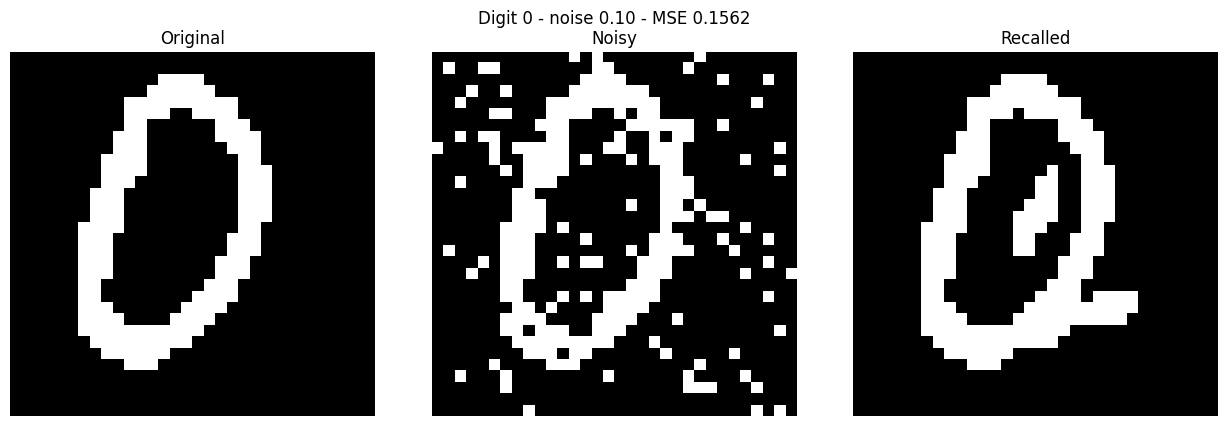

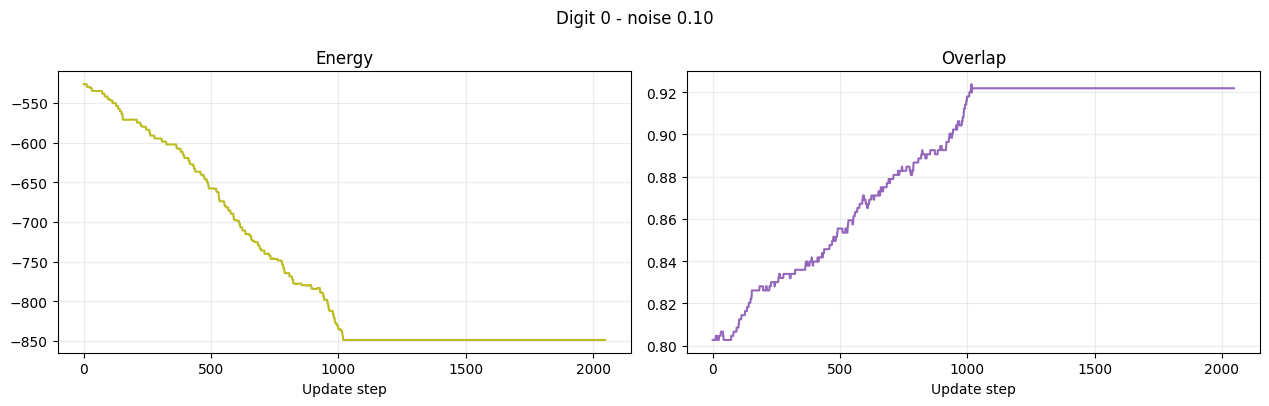

MSE with 0.25 of noise: 0.1562


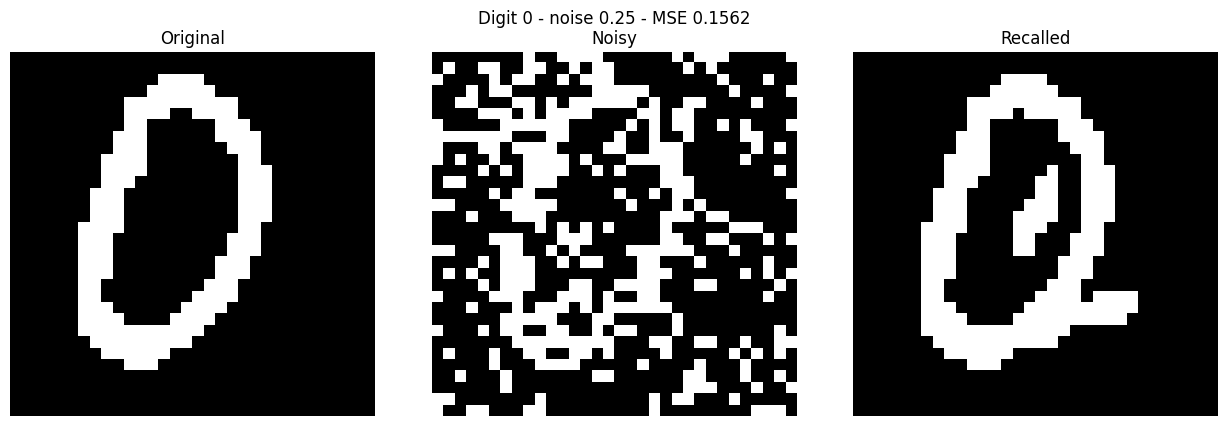

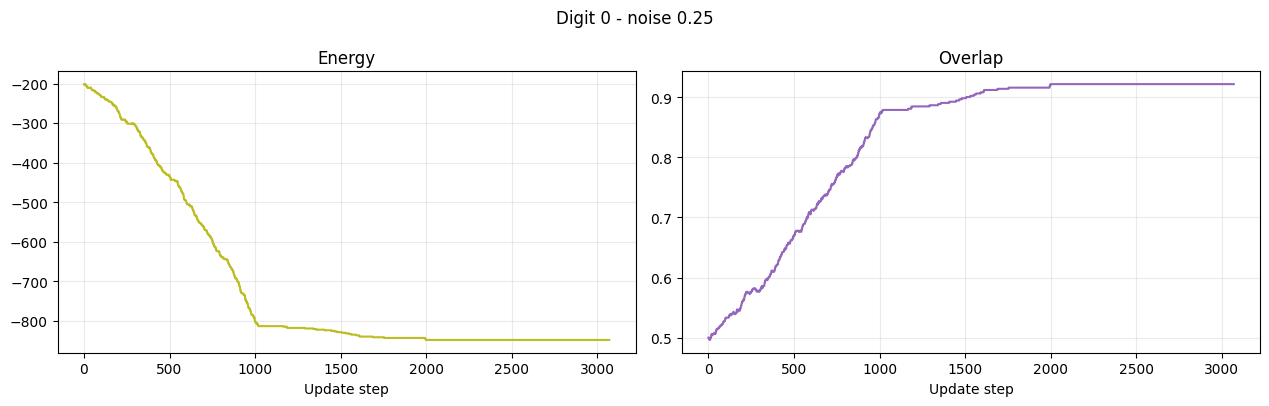

MSE with 0.05 of noise: 0.1875


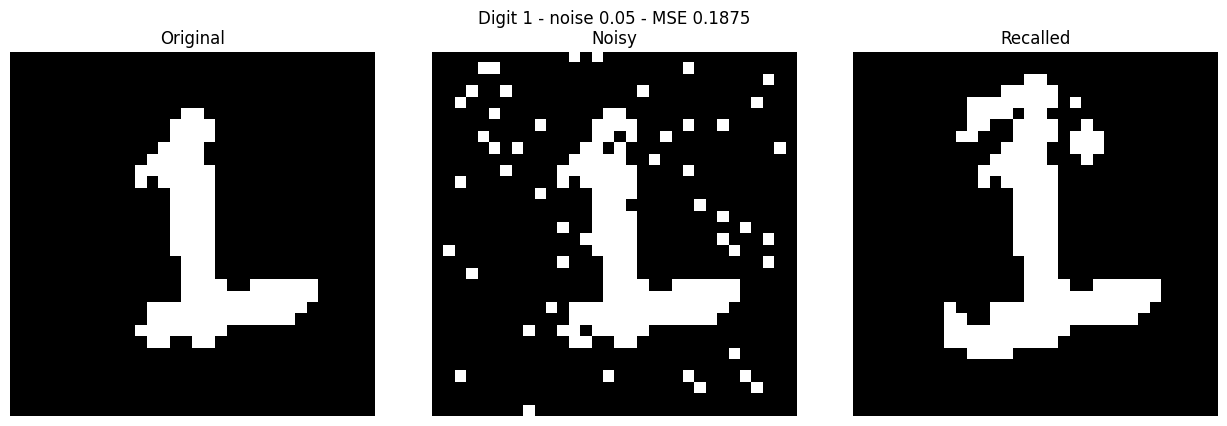

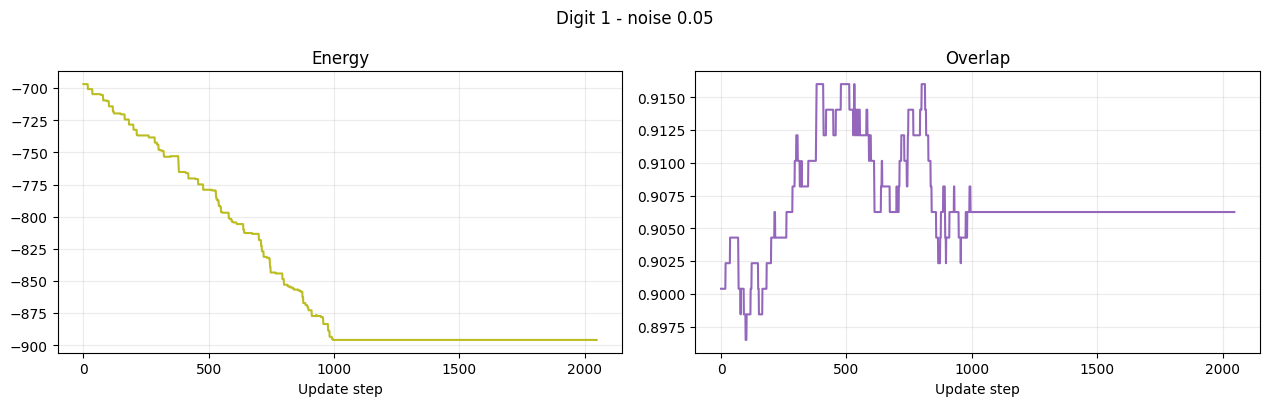

MSE with 0.1 of noise: 0.4297


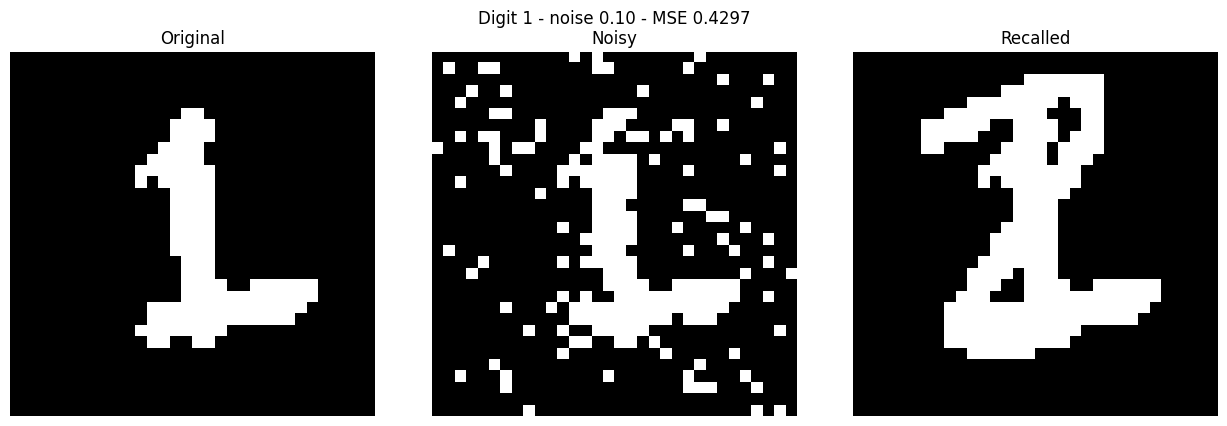

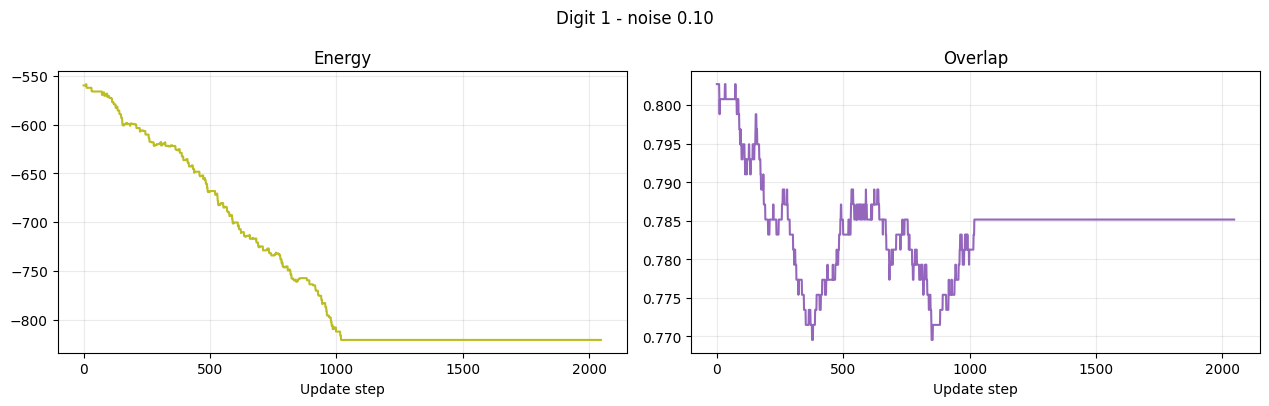

MSE with 0.25 of noise: 1.0352


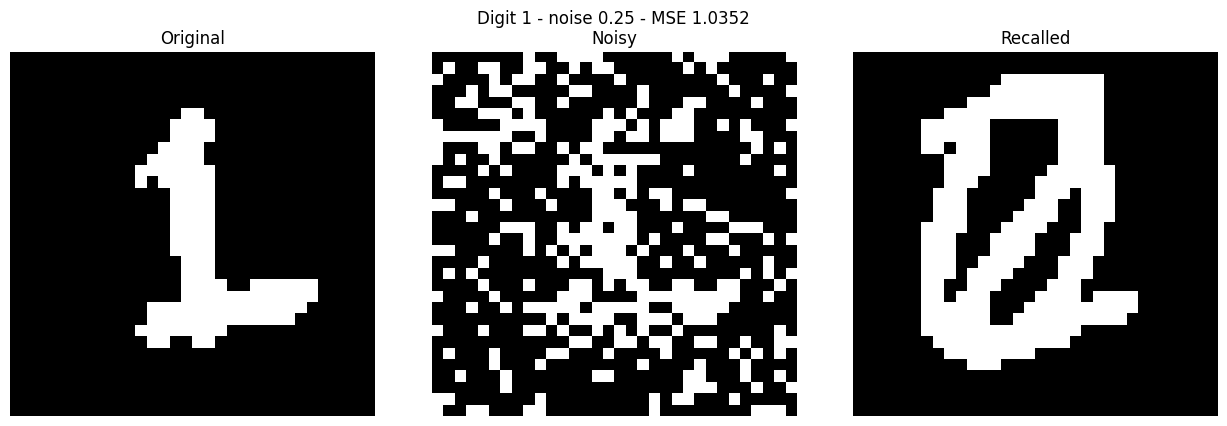

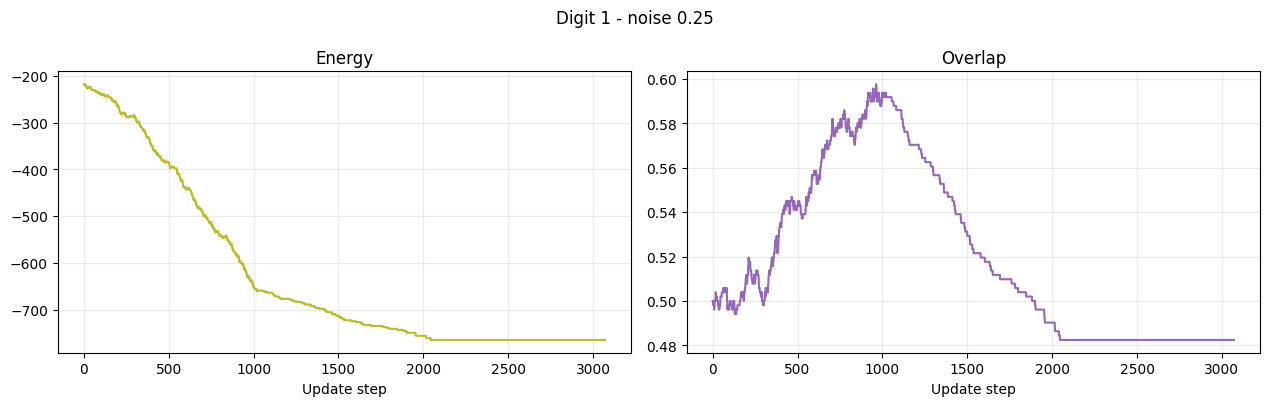

MSE with 0.05 of noise: 0.0469


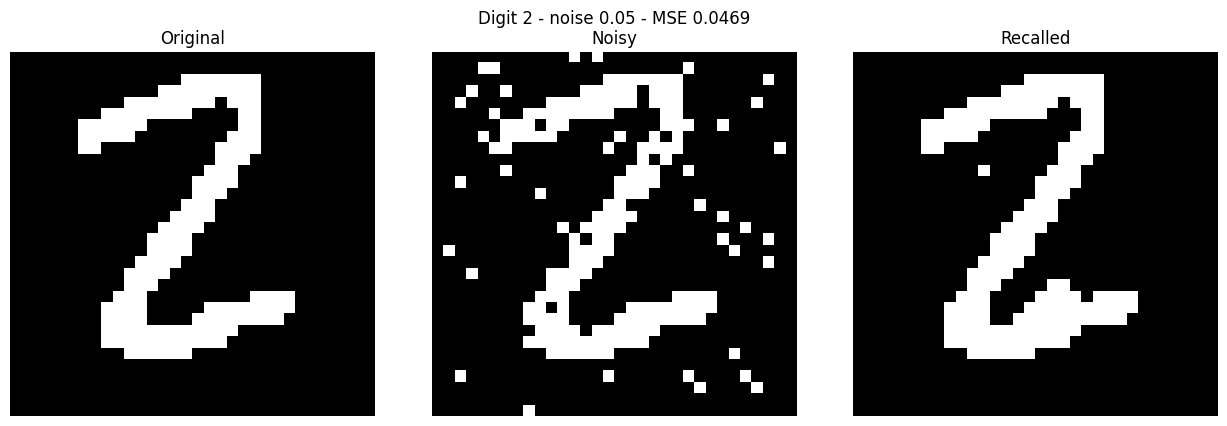

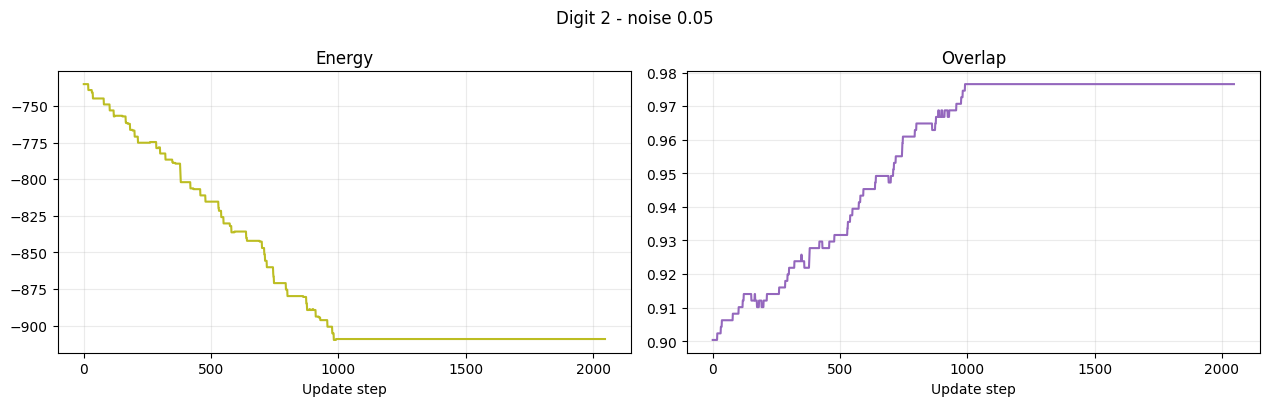

MSE with 0.1 of noise: 0.0469


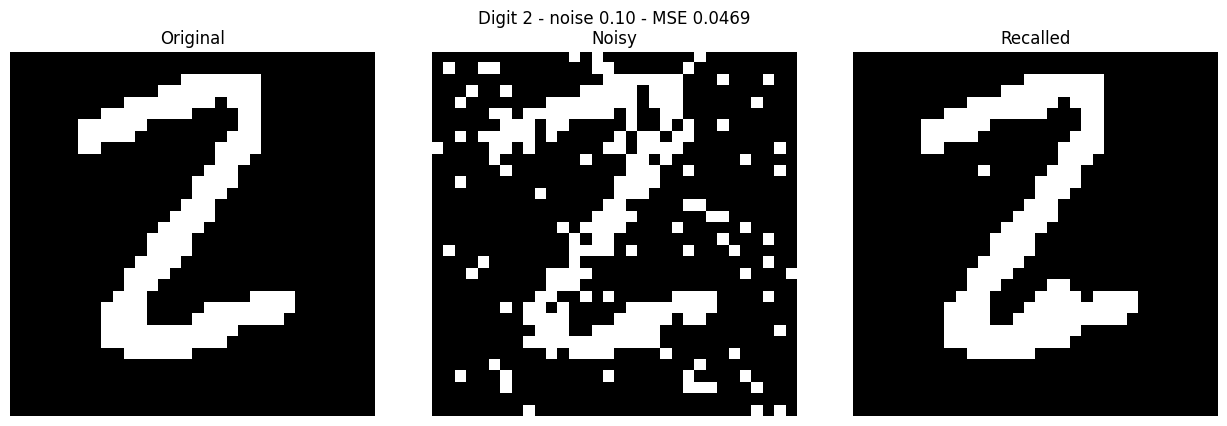

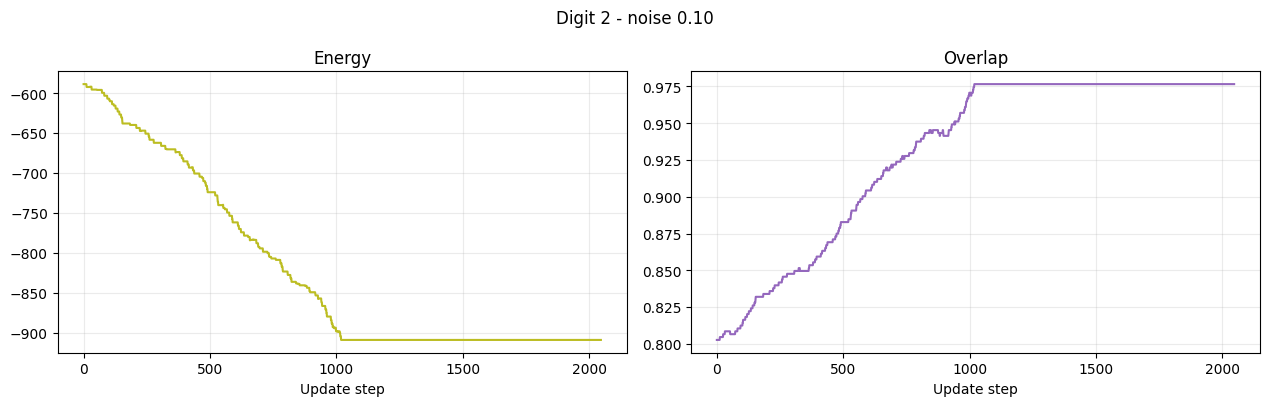

MSE with 0.25 of noise: 0.4219


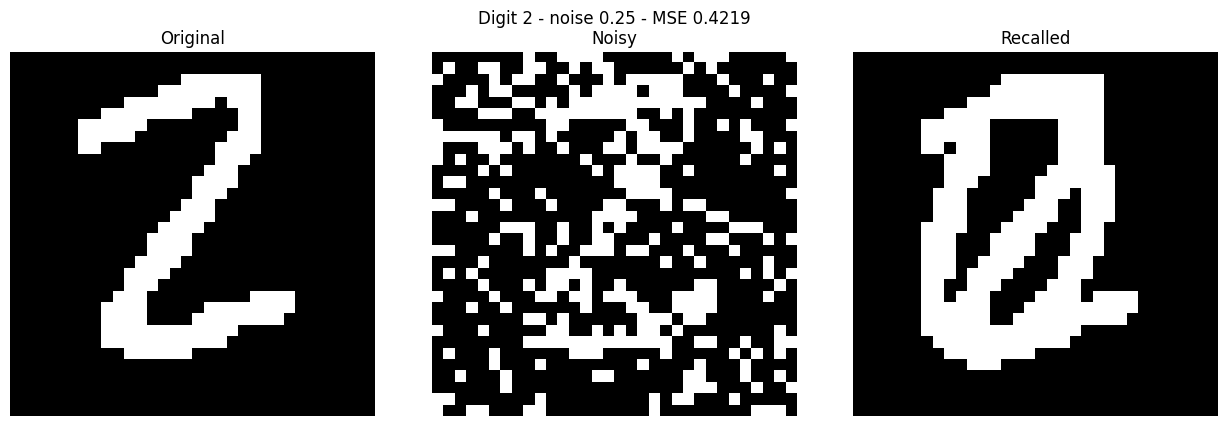

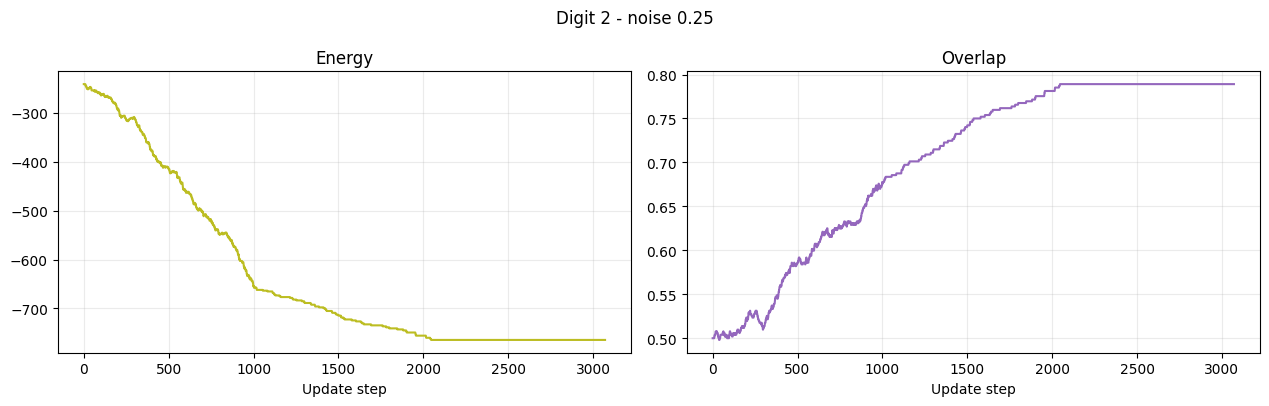

In [4]:
net = HopfieldNetwork(patterns)
bias_per_digit = {0: 0.45, 1: 0.70, 2: 0.70}
max_epochs_per_digit = {0: 10, 1: 100, 2: 100}

for digit in [0, 1, 2]:
    target = patterns[digit]
    d_1 = distort_pattern(target, ratio=0.05, seed=42)
    d_2 = distort_pattern(target, ratio=0.10, seed=42)
    d_3 = distort_pattern(target, ratio=0.25, seed=42)

    noisy_cases = [(0.05, d_1), (0.10, d_2), (0.25, d_3)]
    for noise, noisy in noisy_cases:
        result = net.recall(
            noisy,
            target,
            bias=bias_per_digit[digit],
            max_epochs=max_epochs_per_digit[digit],
        )

        mse = float(np.mean((target - result.recalled) ** 2))
        print(f"MSE with {noise} of noise: {mse:.4f}")

        plot_reconstruction(
            target,
            noisy,
            result.recalled,
            title=f"Digit {digit} - noise {noise:.2f} - MSE {mse:.4f}",
            path=FIG_DIR / f"digit_{digit}_noise_{noise:.2f}_reconstruction.png",
        )

        plot_dynamics(
            result.energies,
            result.overlaps,
            title=f"Digit {digit} - noise {noise:.2f}",
            path=FIG_DIR / f"digit_{digit}_noise_{noise:.2f}_dynamics.png",
        )
